### Data Preprocessing, add tatical features.

In [1]:
import pandas as pd
from src.data_pipeline.feature_engineering import main_data_pipeline
import os
from src.data_pipeline.clean import main_clean_pipeline

BASE_DIR = "./data_match61"

# ------------------------------------------
tournament_csv_path = os.path.join(BASE_DIR, "tournament.csv")
match_csv_path = os.path.join(BASE_DIR, "match.csv")
set_csv_path = os.path.join(BASE_DIR, "set.csv")
rally_csv_path = os.path.join(BASE_DIR, "rally.csv")
shot_csv_path = os.path.join(BASE_DIR, "shot.csv")

# ------------------------------------------
# Keep or remove for columns
# ------------------------------------------
tournament_cols_to_keep = ['tournament_id', 'level']
match_cols_to_keep = ['match_id', 'event','tournament_id','duration','set_count']
shot_cols_to_remove = ['time', 'start_frame_num', 'end_frame_num', 'set_num', 'current_win_score', 
                       'current_lose_score', 'lose_reason', 'score_team']
rally_cols_to_remove = ['start_frame', 'end_frame', 'comment', 'rally_video_check', 'score_reason','shot_count']


# Tournament
tournament_data = pd.read_csv(tournament_csv_path)
tournament_cols_to_remove = tournament_data.columns.difference(tournament_cols_to_keep).tolist()
tournament_data = tournament_data.drop(columns=tournament_cols_to_remove, errors='ignore')
tournament_data['level'] = tournament_data['level'].astype(str).str.replace('Super ', '', case=False).str.strip()

# Match
match_data = pd.read_csv(match_csv_path)
match_data['match_id'] = pd.to_numeric(match_data['match_id'], errors='coerce').fillna(0).astype('Int64')
match_data['event'] = pd.to_numeric(match_data['event'], errors='coerce').fillna(0).astype(int)
match_cols_to_remove = match_data.columns.difference(match_cols_to_keep).tolist()
match_data = match_data.drop(columns=match_cols_to_remove, errors='ignore')

# Set
set_data = pd.read_csv(set_csv_path)
set_data['match_id'] = pd.to_numeric(set_data['match_id'], errors='coerce').astype('Int64')

# Rally
rally_data = pd.read_csv(rally_csv_path)
rally_data = rally_data.drop(columns=rally_cols_to_remove, errors='ignore')

# Shot
shot_data = pd.read_csv(shot_csv_path)
shot_data = shot_data.drop(columns=shot_cols_to_remove, errors='ignore')
shot_data = main_clean_pipeline(shot_data)

# Merge
df_match_rally_shot = pd.merge(
        left=shot_data,
        right=rally_data,
        on='rally_id', 
        how='left'     
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=set_data,
        on='set_id',  
        how='left'
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=match_data,
        on='match_id',  
        how='left'
    )
df_match_rally_shot = pd.merge(
        left=df_match_rally_shot,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )

full_df = main_data_pipeline(df_match_rally_shot)

print("(rows, columns):", full_df.shape)
print("Effective feature：\n", full_df.columns.tolist())
display(full_df.head(10))
OUTPUT_FILE = os.path.join(BASE_DIR, "df_cleaned_with_feature.csv")
full_df.to_csv(OUTPUT_FILE, index=False)


[Start Data Clean]...

--- Data Clean Result ---
Origin 59495 rows
Remove 523 rows (coordinate outlier/unclassified/hit_height=0/Error Case)
Final 58972 rows
--- remove result ---
Origin 58972 rows。
367 rally of Exception
Remove 3703 rows。
Final 55269 rows。

[Data Clean Finished]

--- Clean return height ---

--- 球種映射完成 ---
最終分類結果:
ball_type
網前小球    11472
挑球      11368
殺球       9574
平球       8001
推撲球      4186
發短球      3943
切球       3489
長球       2606
發長球       609
未分類        21
Name: count, dtype: int64

--- 1-16 blocks result---
Hitting_Zone
8     16685
4      7370
6      6972
9      6945
5      5717
3      5681
7      4282
2       965
1       589
13       54
12        4
14        4
11        1
Name: count, dtype: int64

--- Partner Angle Bin result ---
Angle_Bin
0    14043
1     6593
2     7637
3    11952
4    15044
Name: count, dtype: int64

--- add center coverage and formation ---

--- Ball Height Direction result ---
ball_up_down
1    19132
2    19079
0    17058
Name: count, dt

,shot_id,rally_id,shot_num,player,ball_type,backhand,player_A_x,player_A_y,player_B_x,player_B_y,...,shots_to_end,is_defense_failure,player_formation,next_rally_id,next_winner_mid_cover,next_loser_mid_cover,is_reaction_cover,match_Winner_AAI,match_Loser_AAI,ball_up_down
0,1,1,1,5.0,發短球,1,28.639847,94.300792,31.751217,113.677100,...,6,False,Attack,1.0,True,True,True,NaN,0.064047,0
1,2,1,2,7.0,推撲球,1,34.001378,88.407620,32.780770,114.213560,...,5,False,Attack,1.0,True,True,True,0.342563,NaN,0
2,3,1,3,6.0,挑球,1,36.690095,87.092290,36.825915,111.609023,...,4,False,Attack,1.0,True,True,True,NaN,0.013322,1
3,4,1,4,8.0,殺球,0,24.759652,109.455966,48.761037,122.480082,...,3,False,Attack,1.0,True,True,True,0.597411,NaN,2
4,5,1,5,6.0,平球,1,24.160234,111.525887,46.772711,118.061801,...,2,True,Defense,1.0,False,True,False,NaN,0.769209,1
5,6,1,6,7.0,推撲球,0,24.894581,115.227577,46.021033,119.147169,...,1,False,Attack,1.0,False,True,True,0.313007,NaN,2
6,7,1,7,6.0,平球,1,23.988683,114.688232,45.905338,119.146436,...,0,False,Defense,2.0,True,True,NaN,NaN,0.617746,0
7,8,2,1,8.0,發短球,1,30.606006,111.047223,41.950872,93.466893,...,13,False,Attack,2.0,True,True,True,0.372578,NaN,0
8,9,2,2,6.0,網前小球,0,30.711310,108.468965,40.302603,86.235682,...,12,False,Attack,2.0,True,True,True,NaN,0.204983,0
9,10,2,3,8.0,挑球,0,30.268870,112.088710,30.020094,83.111510,...,11,False,Defense,2.0,True,True,True,0.249663,NaN,1


In [2]:
full_df_path = os.path.join(BASE_DIR, "df_cleaned_with_feature.csv")
full_df = pd.read_csv(full_df_path)

C:\Users\Wiki\AppData\Local\Temp\ipykernel_20596\2622452665.py:2: DtypeWarning: Columns (46,62,63) have mixed types. Specify dtype option on import or set low_memory=False.
  full_df = pd.read_csv(full_df_path)


Successfully loaded data, initial number of events: 55269
Filtered out Angle=-404.0 and invalid rows, final number of valid shots: 50633

--- Data Distribution Summary ---
Shot Type Ratio (based on actual count sum):
 ShotType
Defensive Shot    0.66
Offensive Shot    0.34
Name: Count, dtype: float64
Zone Distribution of Defensive Shots (based on actual count sum):
 Zone
Backcourt    0.27
Forecourt    0.10
Midcourt     0.62
Name: Count, dtype: float64
--------------------



c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\general_analyze.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


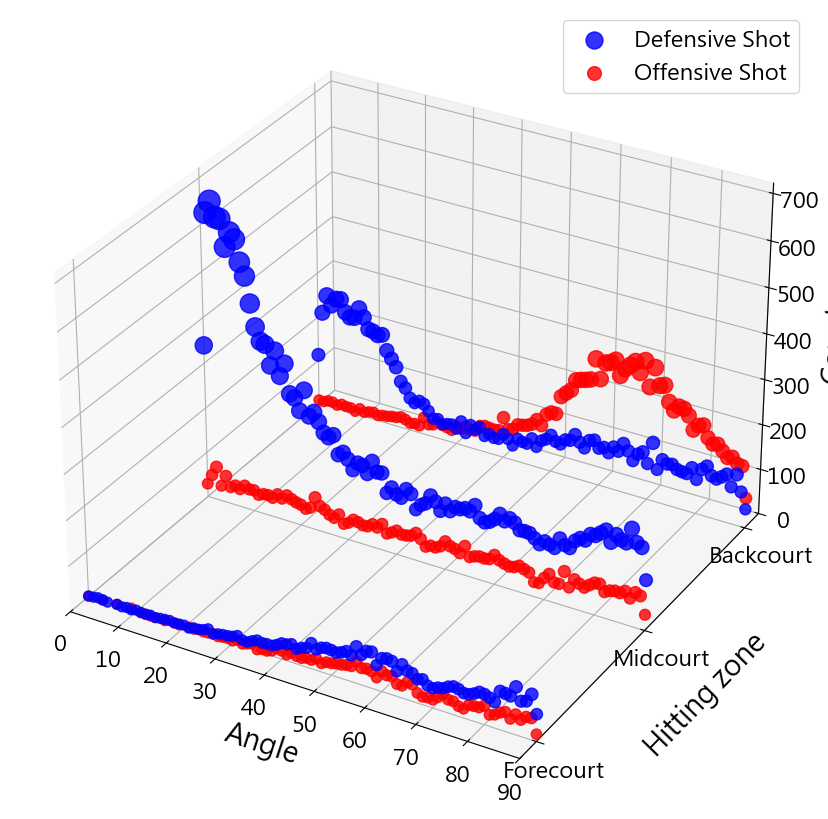

c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\general_analyze.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = df_agg.groupby(['Angle_Group', 'ShotType'])['Count'].sum().unstack(fill_value=0)


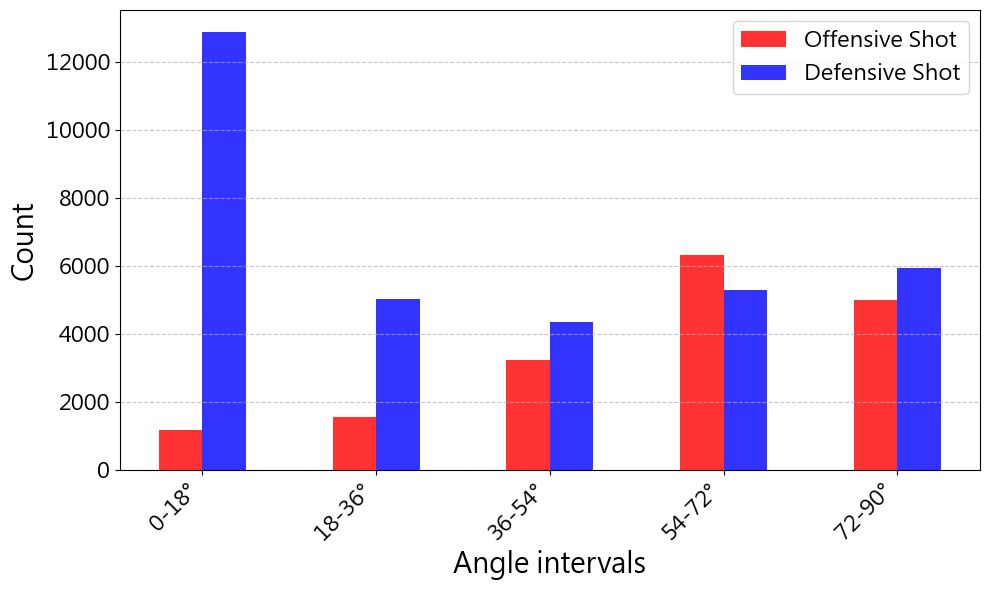

c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\general_analyze.py:349: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(pad=3.0)


Successfully loaded data, original event count: 55269
Filtered Angle=-404.0 and invalid rows, final valid shot events: 50633
Filtered BallType: ['發長球', '發短球', '未分類']

--- Data Distribution Summary ---
Shot Type Ratio (based on actual count sum):
 ShotType
Defensive Shot    0.35
Offensive Shot    0.38
Other Shot        0.28
Name: Count, dtype: float64
Zone Distribution of Defensive Shots (based on actual count sum):
 Zone
Backcourt    0.25
Forecourt    0.10
Midcourt     0.65
Name: Count, dtype: float64
--------------------



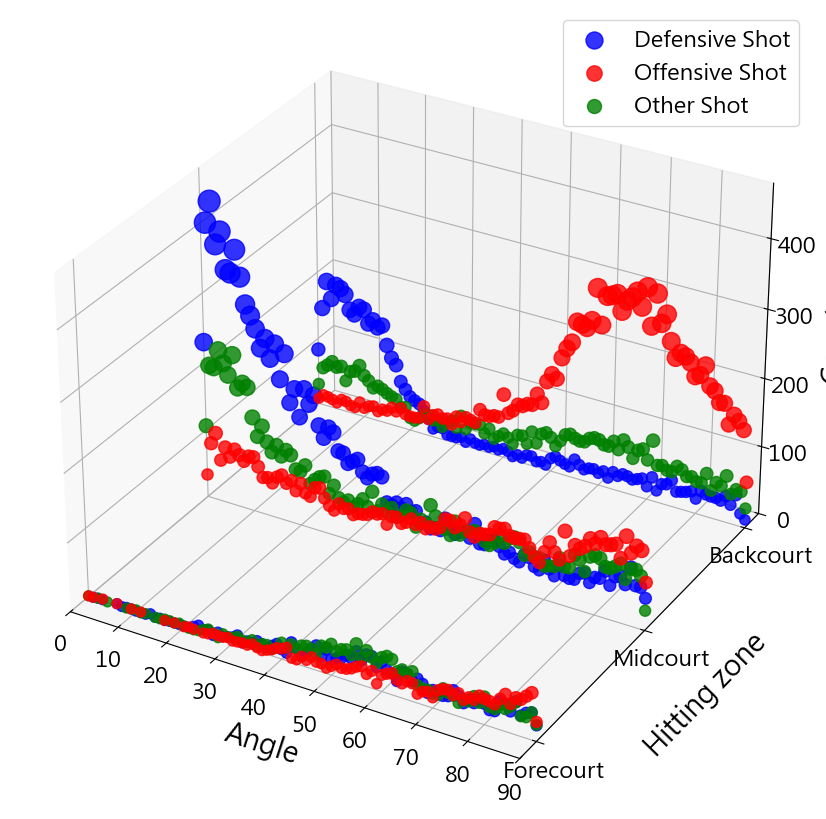

c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\general_analyze.py:363: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_df = df_agg.groupby(['Angle_Group', 'ShotType'])['Count'].sum().unstack(fill_value=0)


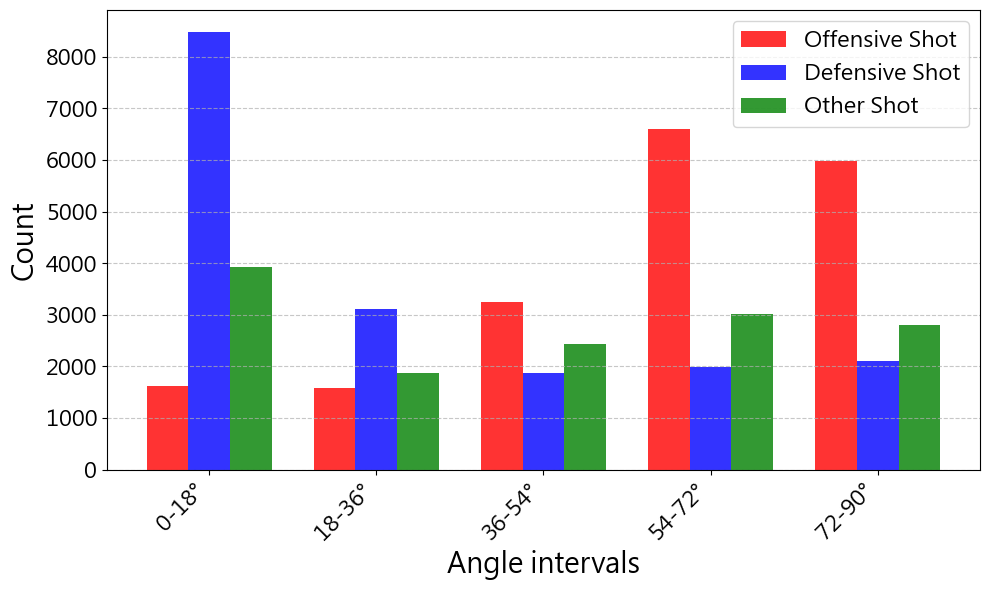

In [3]:
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False
from src.analysis.general_analyze import plot_badminton_shot_analysis, plot_badminton_up_down_analysis, analyze_badminton_rally_stats,  analyze_badminton_shot_distribution


plot_badminton_shot_analysis(full_df)
plot_badminton_up_down_analysis(full_df)

In [4]:
analyze_badminton_rally_stats(full_df)
analyze_badminton_shot_distribution(full_df)

=== Badminton Rally/Shot Statistics ===
event_name  total_rallies  total_shots  average_shots_per_rally  max_shots  min_shots
        MD           1841        15344                     8.33         60          1
        WD           1917        32865                    17.14        186          1
        XD            799         7060                     8.84         60          1
----------------------------------------
Total Rallies: 4557
Total Shots: 55269
Average Shots per Rally: 12.13

--- Final Analysis Report [Count (Percentage)] ---
                        MD             WD             XD           Total
Drop           534 (3.48%)   2723 (8.29%)    232 (3.29%)    3489 (6.31%)
Long Serve     237 (1.54%)    236 (0.72%)    136 (1.93%)     609 (1.10%)
Short Serve  1601 (10.43%)   1680 (5.11%)    662 (9.38%)    3943 (7.13%)
Drive        2950 (19.23%)  3910 (11.90%)  1141 (16.16%)   8001 (14.48%)
Lob          2171 (14.15%)  8278 (25.19%)   919 (13.02%)  11368 (20.57%)
Push/Rush    15

,MD,WD,XD,Total
Drop,534 (3.48%),2723 (8.29%),232 (3.29%),3489 (6.31%)
Long Serve,237 (1.54%),236 (0.72%),136 (1.93%),609 (1.10%)
Short Serve,1601 (10.43%),1680 (5.11%),662 (9.38%),3943 (7.13%)
Drive,2950 (19.23%),3910 (11.90%),1141 (16.16%),8001 (14.48%)
Lob,2171 (14.15%),8278 (25.19%),919 (13.02%),11368 (20.57%)
Push/Rush,1550 (10.10%),2010 (6.12%),626 (8.87%),4186 (7.57%)
Smash,2297 (14.97%),6376 (19.40%),901 (12.76%),9574 (17.32%)
Net Shot,3836 (25.00%),5317 (16.18%),2319 (32.85%),11472 (20.76%)
Clear,163 (1.06%),2321 (7.06%),122 (1.73%),2606 (4.72%)
Total,15344,32865,7060,55269


分析中: 共 26806 筆 Attack 陣型下的擊球數據。

--- Reaction-Cover ---
                   total_attempts  total_failures  failure_rate  success_rate
is_reaction_cover                                                            
True                        23229            2295      9.879892     90.120108
False                        1312             167     12.728659     87.271341

[卡方檢定與效應量]
Chi-square: 10.85
p-value: 0.00099

--- (Chi-Square Test) ---
p-value: 0.00099


c:\Users\Wiki\Desktop\Project\badminton\Badminton\DshuttleSet\src\analysis\cce_analysis.py:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_data[cover_col_name] = valid_data[cover_col_name].astype(bool)


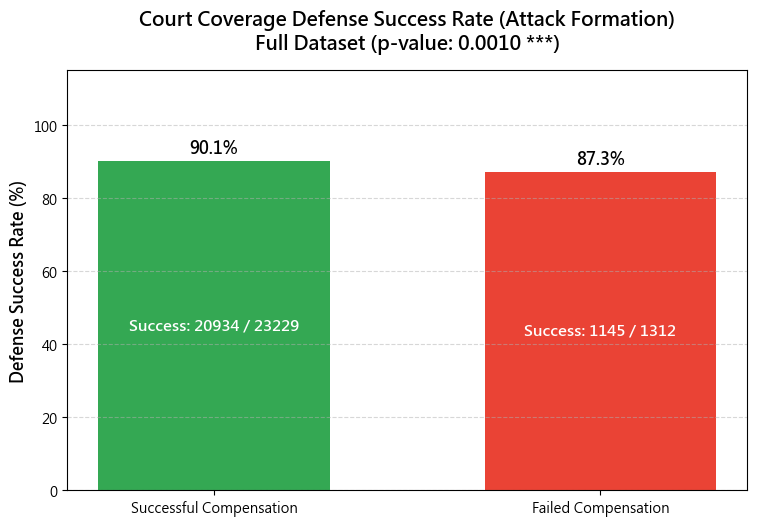

In [5]:
from src.analysis.cce_analysis import global_cce_analysis
global_cce_analysis(full_df, event_type=None
                         , selected_type=['對手落地致勝','未過網','掛網','出界'], shot_to_end=[1,2,3])

 There are 11095 valid records for defense analysis.

[Logistic Regression Analysis for Nonlinear TLAI Effect]
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.9876      0.060    -33.394      0.000      -2.104      -1.871
AAI_scaled_10x    -0.0287      0.058     -0.499      0.618      -0.141       0.084
AAI_squared        0.0375      0.011      3.496      0.000       0.016       0.059

>> Coefficient for quadratic term (AAI_squared) : 0.0375
>> P-value: 0.00047

[TLAI threshold analysis (only showing intervals with sample size >= 100)]
  AAI_bin  Failure_Rate  Sample_Count
0    0.00     12.991803          2440
1    0.05     11.742424          2376
2    0.10     10.443996          1982
3    0.15     12.567976          1655
4    0.20     15.231788          1057
5    0.25     15.755627           622
6    0.30     14.784946           372
7    0.35     18

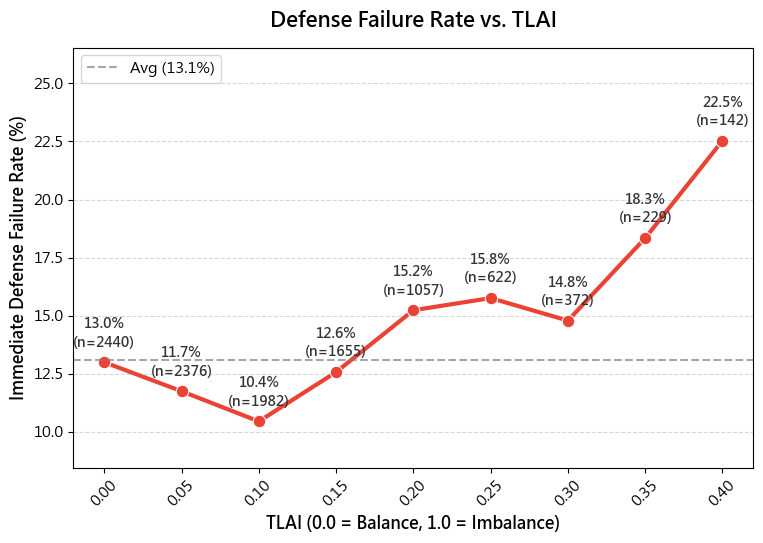

,AAI_bin,Failure_Rate,Sample_Count
0,0.00,12.991803,2440
1,0.05,11.742424,2376
2,0.10,10.443996,1982
3,0.15,12.567976,1655
4,0.20,15.231788,1057
5,0.25,15.755627,622
6,0.30,14.784946,372
7,0.35,18.340611,229
8,0.40,22.535211,142
9,0.45,16.304348,92


In [6]:
from src.analysis.tlai_analysis import analyze_defense_aai
analyze_defense_aai(full_df, threat_shot_types = ['殺球', '切球'])

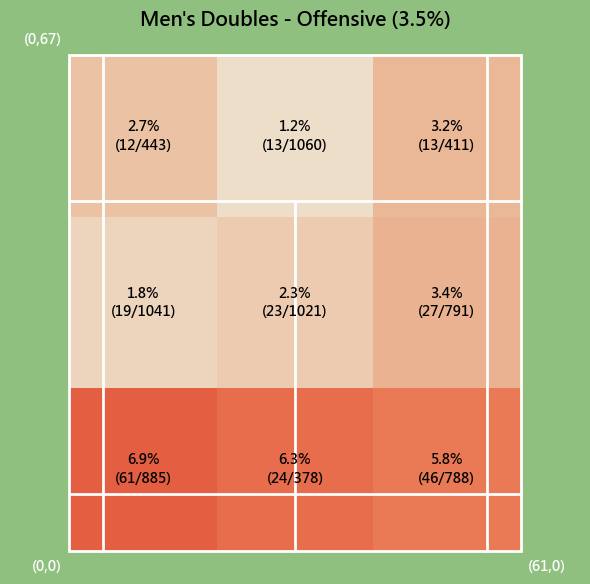

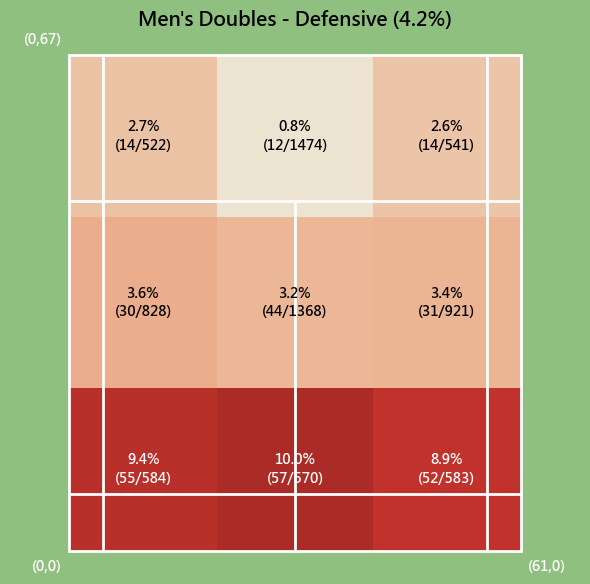

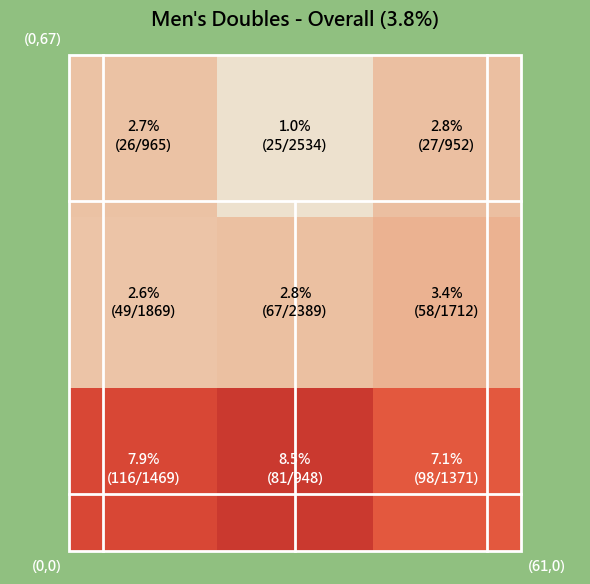

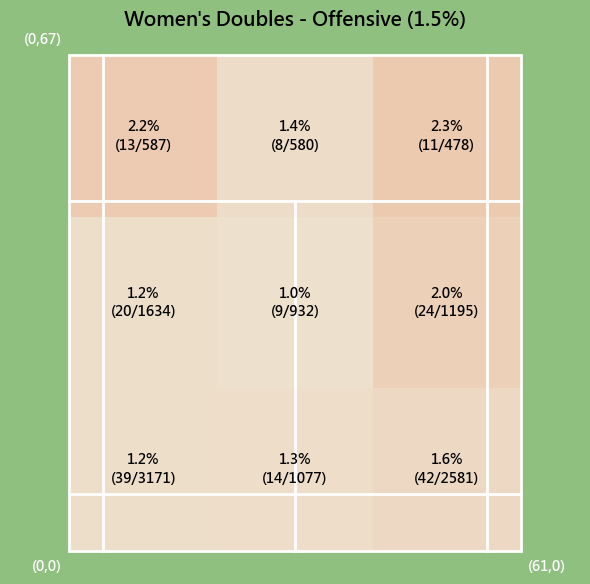

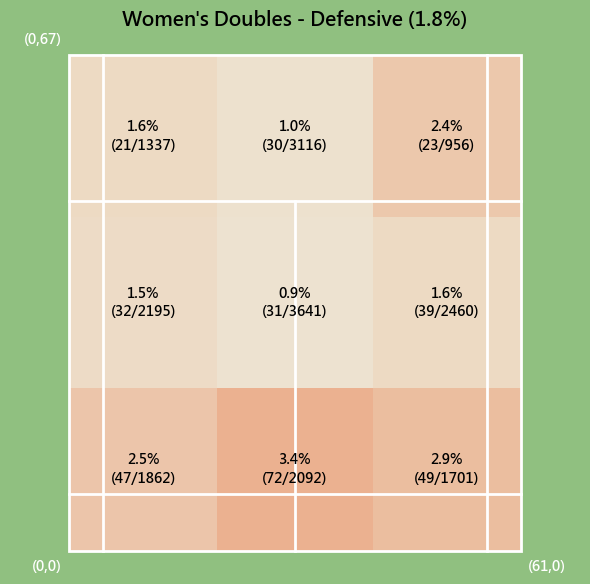

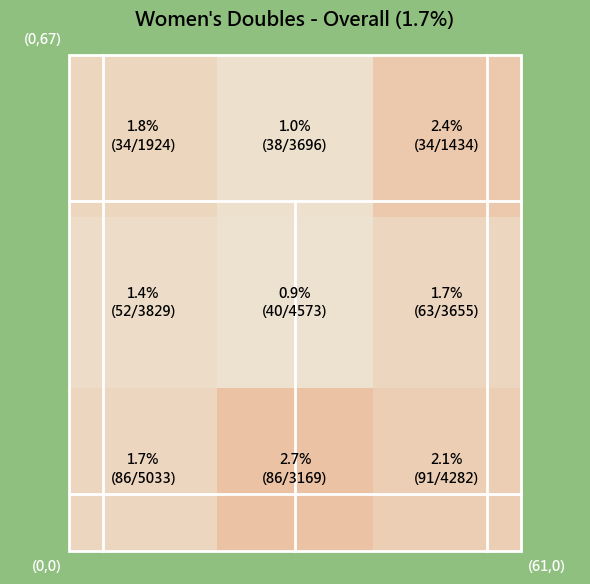

In [7]:
from src.analysis.defensive_failure import analyze_defensive_failure_rate
analyze_defensive_failure_rate(full_df, event_type=1)
analyze_defensive_failure_rate(full_df, event_type=2)

An error occurred: [Errno 2] No such file or directory: './img/matches/intensity_analysis.png'


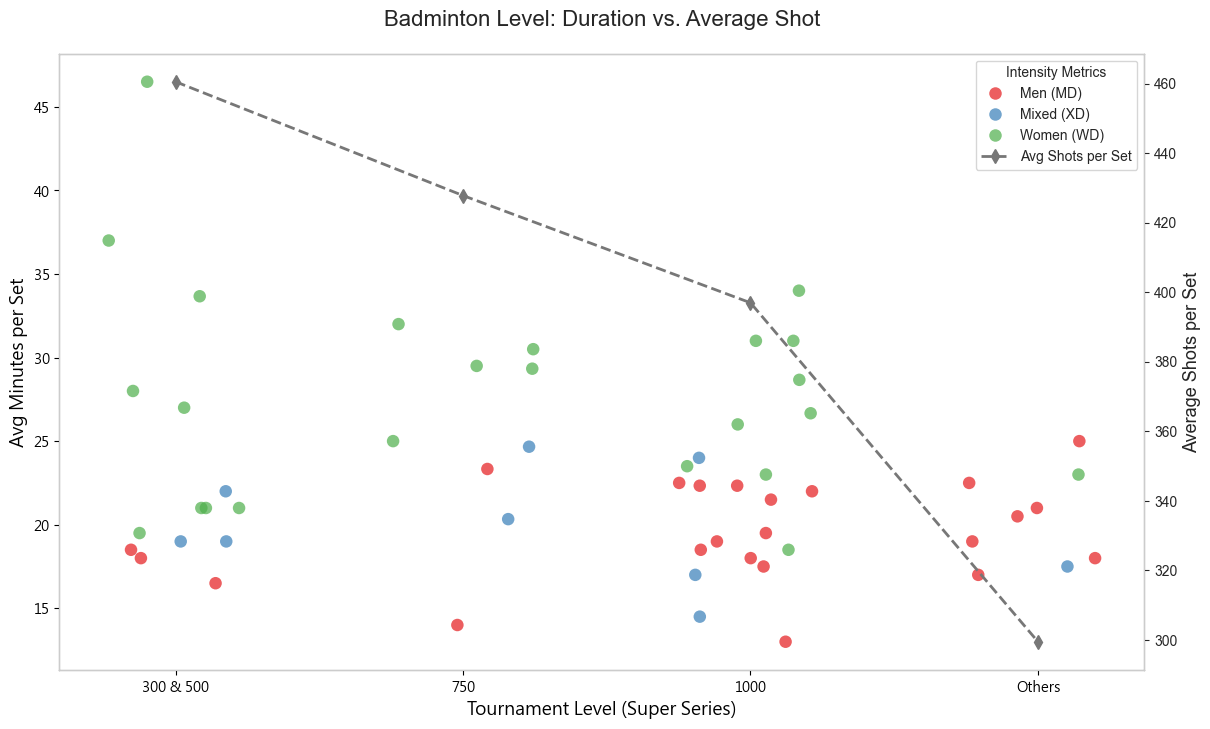

In [8]:
from src.analysis.matches_analyze import plot_badminton_intensity

match_tour_data = pd.merge(
        left=match_data,
        right=tournament_data,
        on='tournament_id',  
        how='left'
    )
plot_badminton_intensity(match_tour_data,df_match_rally_shot)